In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.feature_selection import VarianceThreshold, SelectFromModel, RFE
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import mannwhitneyu
from xgboost import XGBClassifier
from worcgist.load_data import load_data
warnings.filterwarnings('ignore')

The number of samples: 246
The number of columns: 494

Total missing values: 0

--- Data Info ---
<class 'pandas.DataFrame'>
Index: 246 entries, GIST-001_0 to GIST-246_0
Columns: 494 entries, label to PREDICT_original_phasef_phasesym_entropy_WL3_N5
dtypes: float64(468), int64(25), str(1)
memory usage: 951.3+ KB

Label distribution:
label
GIST        125
non-GIST    121
Name: count, dtype: int64


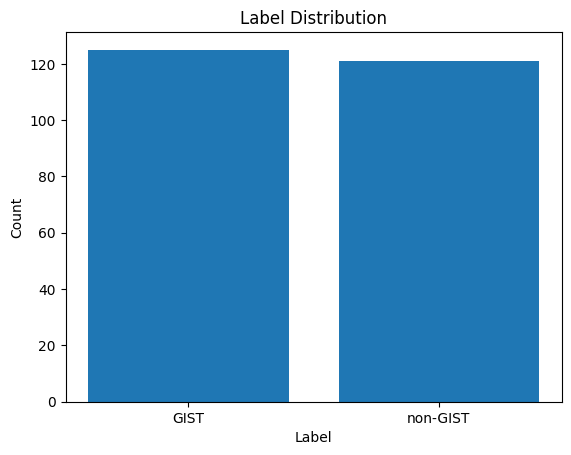

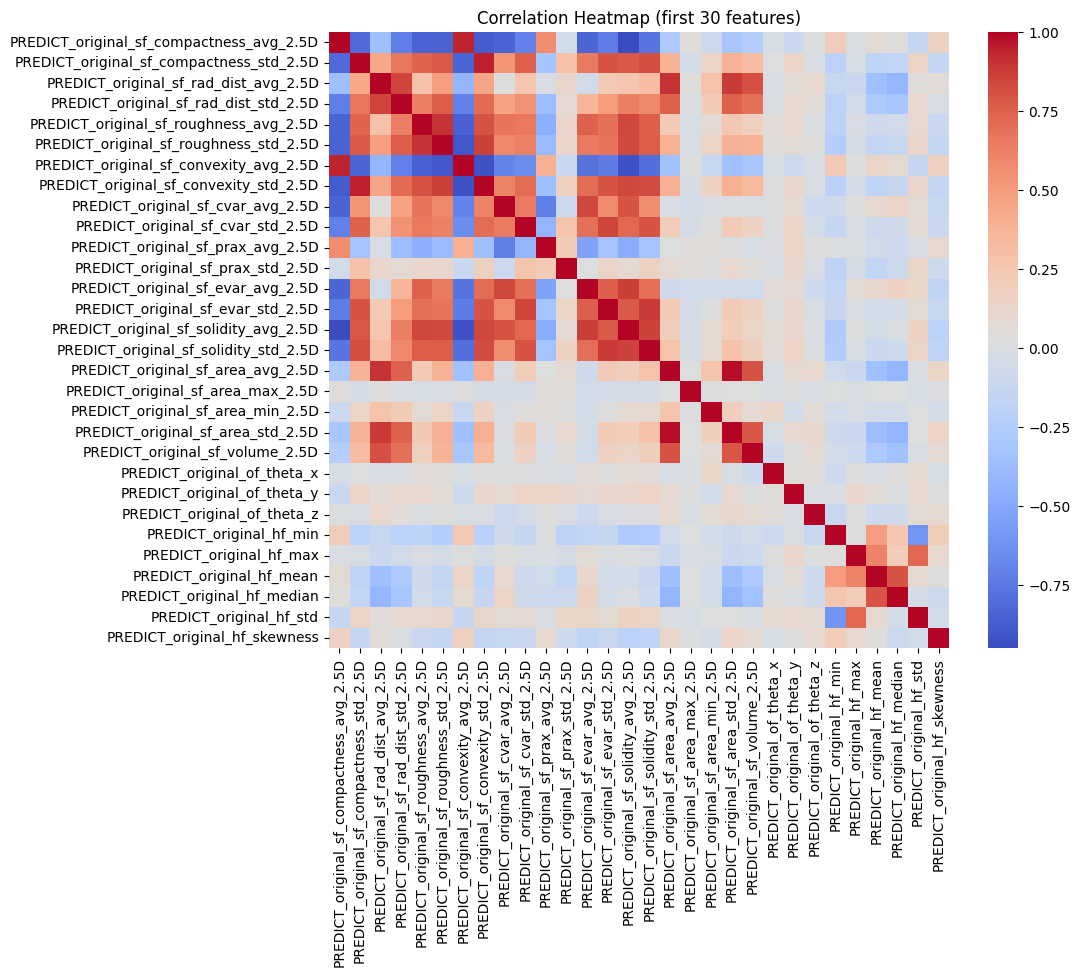

In [3]:
#----------Data Loading and Inspection-----------

# Data loading functions.
data = load_data()
print(f'The number of samples: {len(data.index)}')
print(f'The number of columns: {len(data.columns)}')

#Show missing data
total_missing = data.isnull().sum().sum()
print(f'\nTotal missing values: {total_missing}')
#Show data info
print("\n--- Data Info ---")
data.info()

#Show label distribution
print(f'\nLabel distribution:')
print(data['label'].value_counts())
plt.bar(data['label'].value_counts().index, data['label'].value_counts().values)
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Label Distribution')
plt.show()

#Show data correlation
features_subset = data.select_dtypes(include=['float64', 'int64']).iloc[:, :30]
corr_matrix = features_subset.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap (first 30 features)')
plt.show()

In [4]:
#-----------Data Preprocessing-----------
# Label encoding (Switch Gist and non-Gist to 1 and 0 respectively) and delete first column (ID)
label_encoder = LabelEncoder()
data['label'] = label_encoder.fit_transform(data['label'])
print(f'\nLabel encoding mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}')

# Train-test split (80-20 split, stratify on label)
X = data.drop(['label'], axis=1)
y = data['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'\nTraining set size: {X_train.shape[0]} samples')
print(f'Testing set size: {X_test.shape[0]} samples')

# Variance thresholding (remove features with low variance)
selector = VarianceThreshold(threshold=0.01)
X_train_selected = pd.DataFrame(selector.fit_transform(X_train), 
                                columns=X_train.columns[selector.get_support()])
X_test_selected = pd.DataFrame(selector.transform(X_test), 
                               columns=X_train.columns[selector.get_support()])

# Data scaling
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_selected), columns=X_train_selected.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_selected), columns=X_test_selected.columns)

# Correlation filtering
corr_matrix = X_train_scaled.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
X_train_final = X_train_scaled.drop(columns=to_drop)
X_test_final = X_test_scaled.drop(columns=to_drop)

print(f'\nNumber of features before variance thresholding: {X_train.shape[1]}')
print(f'Number of features after variance thresholding: {X_train_selected.shape[1]}')
print(f'Final number of features after preprocessing: {X_train_final.shape[1]}')


Label encoding mapping: {'GIST': np.int64(0), 'non-GIST': np.int64(1)}

Training set size: 196 samples
Testing set size: 50 samples

Number of features before variance thresholding: 493
Number of features after variance thresholding: 352
Final number of features after preprocessing: 181


In [5]:
#----------Feature selection and modeling-----------
X_train_final = X_train_final.reset_index(drop=True)
X_test_final = X_test_final.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Mann-Whitney U test for feature selection
def get_top_20_mwu(X_fold_train, y_fold_train):
    p_values = []
    #Calculate the difference between GIST (1) and non-GIST (0)
    for col in X_fold_train.columns:
        group_gist = X_fold_train.loc[y_fold_train == 1, col]
        group_nongist = X_fold_train.loc[y_fold_train == 0, col]
        # Perform the Mann-Whitney U test
        stat, p = mannwhitneyu(group_gist, group_nongist)
        p_values.append((col, p))
    
    # Sort the list based on the p-value (from low to high)
    p_values.sort(key=lambda x: x[1])
    
    # Select the names of the top 20 features
    top_20_features = [item[0] for item in p_values[:20]]
    return top_20_features

#LASSO
lasso_selector = SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', random_state=42), 
                                 max_features=20, threshold=-np.inf)

#RFE
rfe_selector = RFE(estimator=RandomForestClassifier(random_state=42, n_jobs=-1), n_features_to_select=20, step = 5)

# Define classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=2000,random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

# Evaluation loop
feature_selection_names = ['Mann-Whitney U', 'LASSO']

for fs_name in feature_selection_names:
    for clf_name, clf in classifiers.items():
        
        fold_accuracies = [] 
        
        # Loop of 5 folds
        for train_index, val_index in skf.split(X_train_final, y_train):
            
            # split data in fold train en fold val
            X_fold_train = X_train_final.iloc[train_index]
            X_fold_val = X_train_final.iloc[val_index]
            y_fold_train = y_train.iloc[train_index]
            y_fold_val = y_train.iloc[val_index]
            
            # Step A: feature selection on fold train, apply the same selection to fold val
            if fs_name == 'Mann-Whitney U':
                selected_cols = get_top_20_mwu(X_fold_train, y_fold_train)
                X_fold_train_sel = X_fold_train[selected_cols]
                X_fold_val_sel = X_fold_val[selected_cols]
                
            elif fs_name == 'LASSO':
                lasso_selector.fit(X_fold_train, y_fold_train)
                selected_cols = X_fold_train.columns[lasso_selector.get_support()]
                X_fold_train_sel = X_fold_train[selected_cols]
                X_fold_val_sel = X_fold_val[selected_cols]
                
            elif fs_name == 'RFE':
                rfe_selector.fit(X_fold_train, y_fold_train)
                selected_cols = X_fold_train.columns[rfe_selector.get_support()]
                X_fold_train_sel = X_fold_train[selected_cols]
                X_fold_val_sel = X_fold_val[selected_cols]
                
            # Step B: train classifier on fold train (with selected features), test on fold val
            clf.fit(X_fold_train_sel, y_fold_train)
            y_pred = clf.predict(X_fold_val_sel)
            
            # calculate accuracy for this fold and store it
            acc = accuracy_score(y_fold_val, y_pred)
            fold_accuracies.append(acc)
            
        # Calculate the mean accuracy across the 5 folds for this feature selection + classifier combination
        mean_acc = np.mean(fold_accuracies)
        
        results.append({
            'Feature Selection': fs_name,
            'Classifier': clf_name,
            'Mean CV Accuracy': mean_acc
        })
        print(f"✔️ {fs_name} + {clf_name}: Mean CV Accuracy = {mean_acc:.3f}")

# Results presentation
results_df = pd.DataFrame(results)
print("\n RESULTS  (sorted on best mean CV Accuracy):")
print(results_df.sort_values(by='Mean CV Accuracy', ascending=False).to_string(index=False))

✔️ Mann-Whitney U + Logistic Regression: Mean CV Accuracy = 0.551
✔️ Mann-Whitney U + Random Forest: Mean CV Accuracy = 0.637
✔️ Mann-Whitney U + SVM: Mean CV Accuracy = 0.510
✔️ Mann-Whitney U + XGBoost: Mean CV Accuracy = 0.571
✔️ LASSO + Logistic Regression: Mean CV Accuracy = 0.556
✔️ LASSO + Random Forest: Mean CV Accuracy = 0.581
✔️ LASSO + SVM: Mean CV Accuracy = 0.613
✔️ LASSO + XGBoost: Mean CV Accuracy = 0.561

 RESULTS  (sorted on best mean CV Accuracy):
Feature Selection          Classifier  Mean CV Accuracy
   Mann-Whitney U       Random Forest          0.637179
            LASSO                 SVM          0.612564
            LASSO       Random Forest          0.581282
   Mann-Whitney U             XGBoost          0.570897
            LASSO             XGBoost          0.561282
            LASSO Logistic Regression          0.556154
   Mann-Whitney U Logistic Regression          0.551154
   Mann-Whitney U                 SVM          0.510256


In [6]:
#----------Hyyperparameter tuning of best model (XGBoost with Mann-Whitney U)-----------
# 1. Create a custom Scikit-Learn Transformer for the Mann-Whitney U test
class MWUSelector(BaseEstimator, TransformerMixin):
    def __init__(self, k=20):
        self.k = k # The number of features to select
        self.selected_columns_ = None
        
    def fit(self, X, y):
        p_values = []
        # Calculate the p-value for each column
        for col in X.columns:
            group_gist = X.loc[y == 1, col]
            group_nongist = X.loc[y == 0, col]
            stat, p = mannwhitneyu(group_gist, group_nongist)
            p_values.append((col, p))
            
        # Sort by p-value
        p_values.sort(key=lambda x: x[1])
        
        # Save the names of the top 'k' features
        self.selected_columns_ = [item[0] for item in p_values[:self.k]]
        return self
    
    def transform(self, X):
        # Return only the selected columns
        return X[self.selected_columns_]

# 2. Build the Pipeline (The assembly line)
# First step: Feature selection ('mwu')
# Second step: The Classifier ('rf')
pipeline = Pipeline([
    ('mwu', MWUSelector()), 
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# 3. Define the parameter grid
# We use 'stepname__parametername' to tell GridSearchCV which setting belongs to which step!
param_grid = {
    'mwu__k': [10, 15, 20, 25, 30],           # Test different numbers of features!
    'rf__n_estimators': [50, 100, 200],       # Number of trees
    'rf__max_depth': [None, 5, 10],           # Max depth of the trees
    'rf__min_samples_split': [2, 5],          # Min samples to split
    'rf__min_samples_leaf': [1, 2]            # Min samples per leaf
}

print("\n🚀 Starting Pipeline Tuning (Testing features AND model settings simultaneously)...")

# 4. Set up the Grid Search
# We feed it the entire pipeline instead of just the model
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, 
                           cv=5, scoring='accuracy', verbose=1)

# 5. Start training! 
# Notice we give it the full datasets (X_train_final). 
# The pipeline will automatically handle the MWU feature selection internally for each fold!
grid_search.fit(X_train_final, y_train)

# 6. Print the results
print("\n🏆 --- Ultimate Tuning Results --- 🏆")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.3f}")


🚀 Starting Pipeline Tuning (Testing features AND model settings simultaneously)...
Fitting 5 folds for each of 180 candidates, totalling 900 fits

🏆 --- Ultimate Tuning Results --- 🏆
Best parameters found: {'mwu__k': 20, 'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 50}
Best Cross-Validation Accuracy: 0.633



🌟 Final Accuracy on the unseen Test Set: 0.560 🌟

✨ The winning model used 20 features. Generating plot...


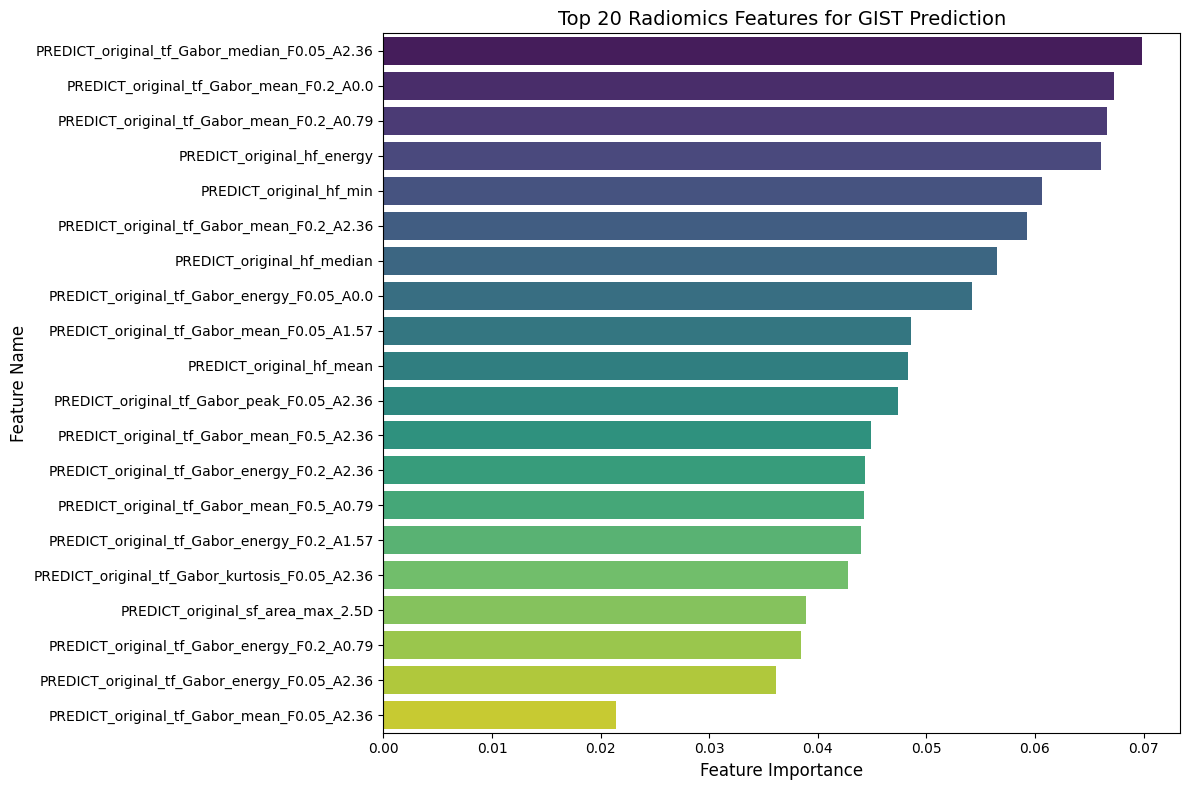

In [7]:
# 7. Final evaluation on the unseen Test Set
# The grid search automatically saved the best pipeline!
best_pipeline = grid_search.best_estimator_

# Predict the outcomes for the unseen test patients
y_pred_test = best_pipeline.predict(X_test_final)

# Calculate the final accuracy
final_accuracy = accuracy_score(y_test, y_pred_test)
print(f"\n🌟 Final Accuracy on the unseen Test Set: {final_accuracy:.3f} 🌟")

# 8. Feature Importance Visualization
best_k = grid_search.best_params_['mwu__k']
print(f"\n✨ The winning model used {best_k} features. Generating plot...")

# Extract the selected feature names from the MWU step in the pipeline
mwu_step = best_pipeline.named_steps['mwu']
selected_features = mwu_step.selected_columns_

# Extract the trained Random Forest model from the pipeline
rf_step = best_pipeline.named_steps['rf']
importances = rf_step.feature_importances_

# Create a clean DataFrame for the plot
feature_imp_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the feature importances using Seaborn
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title(f'Top {best_k} Radiomics Features for GIST Prediction', fontsize=14)
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout() # Ensures the long radiomics names fit on the screen
plt.show()